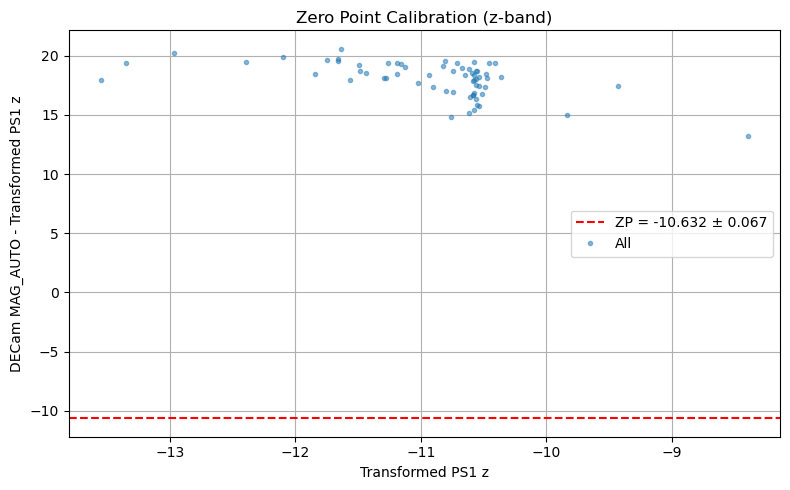

ZP = -10.632 ± 0.067


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip



# Read DECam catalog
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# Read Pan-STARRS catalog
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# Compute transformed z-band PS1 mag to DECam system (Eq. 2)
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return z_ps1 - 0.114 * (r_ps1 - i_ps1) - 0.010

# Compute zero point
def compute_zero_point(decam_df, ps_df):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    # Transform PS1 mags
    mag_ps_transformed = compute_transformed_z(ps_df)

    # Mask bad PS1 values (e.g. placeholder 999 or outliers)
    bad_ps_mask = (ps_df["zPSFMag"] > 50) | (ps_df["rPSFMag"] > 20) | (ps_df["iPSFMag"] > 20)
    bad_ps_mask |= (ps_df["zPSFMag"] < -10) | (ps_df["rPSFMag"] < -10) | (ps_df["iPSFMag"] < -10)

    # Combine all masks
    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    delta_mag = mag_decam - mag_ps_transformed

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3.0, high=3.0)
    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Plot: DECam - PS1 vs PS1
    plt.figure(figsize=(8, 5))
    plt.errorbar(delta_mag,mag_ps_transformed,   fmt='o', ms=3, alpha=0.5, label="All")
    plt.axhline(zp, color='r', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 z")
    plt.ylabel("DECam MAG_AUTO - Transformed PS1 z")
    plt.title("Zero Point Calibration (z-band)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return zp, zp_err


# Run for specific files (already cross-matched)
decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/z_band_decam_matched.cat"
ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/z_band_panstarrs_matched.csv"

decam_df = read_decam_catalog(decam_path)
ps_df = read_ps_catalog(ps_path)

if len(decam_df) != len(ps_df):
    print("Warning: Catalog lengths do not match. Ensure row-by-row match.")
else:
    zp, zp_err = compute_zero_point(decam_df, ps_df)
    print(f"ZP = {zp:.3f} ± {zp_err:.3f}")


# markdown i band

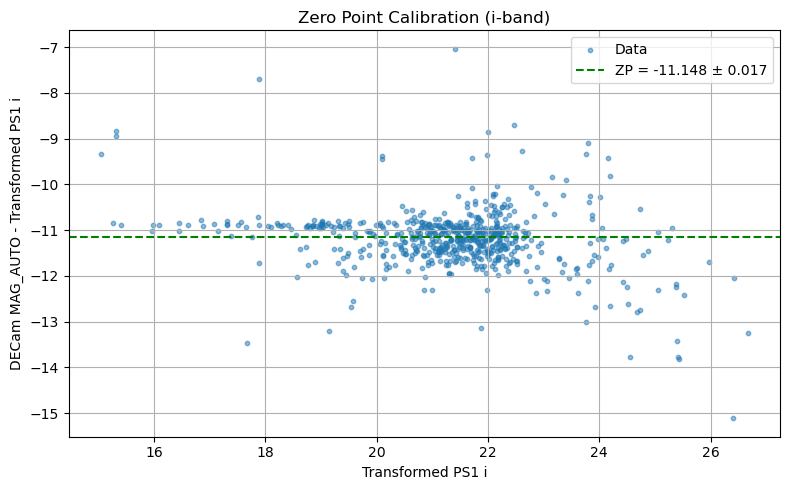

ZP = -11.148 ± 0.017


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip



# Read DECam catalog
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# Read Pan-STARRS catalog
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# Compute transformed z-band PS1 mag to DECam system (Eq. 2)
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

# Compute zero point
from scipy.stats import linregress

def compute_zero_point(decam_df, ps_df):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    # Transform PS1 mags
    mag_ps_transformed = compute_transformed_z(ps_df)

    # Mask bad PS1 values
    bad_ps_mask = (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100)
    bad_ps_mask |= (ps_df["zPSFMag"] < -10) | (ps_df["rPSFMag"] < -10) | (ps_df["iPSFMag"] < -10)

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]
    delta_mag = mag_decam - mag_ps_transformed

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3.0, high=3.0)#3 sigma clipping
    clipped = clipped[~np.isnan(clipped)]  # Remove NaNs after clipping
    clipped = clipped[~np.isinf(clipped)]  # Remove Infs after clipping 
    zp = np.median(clipped) # median of clipped values
    # Calculate standard deviation and error to determine the zero point
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Linear fit:
    #slope, intercept, r_value, p_value, std_err = linregress(mag_ps_transformed, delta_mag)
    #fit_line = slope * mag_ps_transformed + intercept

    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(mag_ps_transformed, delta_mag, s=10, alpha=0.5, label="Data")
    #plt.plot(mag_ps_transformed, fit_line, 'r-', label=f'Fit: y = {slope:.3f}x + {intercept:.3f}')
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 i")
    plt.ylabel("DECam MAG_AUTO - Transformed PS1 i")
    plt.title("Zero Point Calibration (i-band)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    #print(f"Slope = {slope:.4f}, Intercept = {intercept:.4f}, R² = {r_value**2:.4f}")

    return zp, zp_err



# Run for specific files (already cross-matched)
decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/i_band_depth_decam_matched.cat"
ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/i_band_depth_panstarrs_matched.csv"

decam_df = read_decam_catalog(decam_path)
ps_df = read_ps_catalog(ps_path)

if len(decam_df) != len(ps_df):
    print("Warning: Catalog lengths do not match. Ensure row-by-row match.")
else:
    zp, zp_err = compute_zero_point(decam_df, ps_df)
    print(f"ZP = {zp:.3f} ± {zp_err:.3f}")


# markdown z band

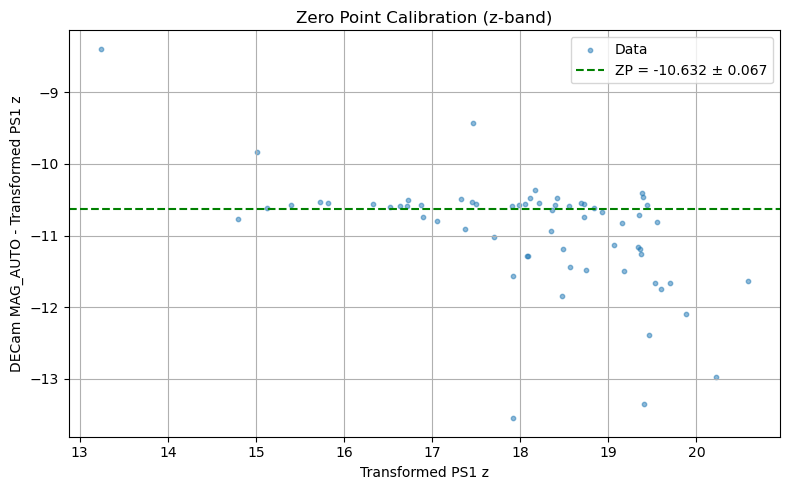

ZP = -10.632 ± 0.067


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip, linregress

# Read DECam catalog
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# Read Pan-STARRS catalog
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# Compute transformed i-band PS1 mag to DECam system (Eq. for i-band)
def compute_transformed_i(ps_df):
    i_ps1 = ps_df["iPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    z_ps1 = ps_df["zPSFMag"]
    return z_ps1 - 0.114 * (r_ps1 - i_ps1) -  0.010

# Compute zero point
def compute_zero_point(decam_df, ps_df):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    # Transform PS1 mags to DECam i-band
    mag_ps_transformed = compute_transformed_i(ps_df)

    # Mask bad PS1 values
    bad_ps_mask = (ps_df["zPSFMag"] > 50) | (ps_df["rPSFMag"] > 20) | (ps_df["iPSFMag"] > 20)
    bad_ps_mask |= (ps_df["zPSFMag"] < -10) | (ps_df["rPSFMag"] < -10) | (ps_df["iPSFMag"] < -10)

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]
    delta_mag = mag_decam - mag_ps_transformed

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3.0, high=3.0)
    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Linear fit: y = slope * x + intercept
    slope, intercept, r_value, p_value, std_err = linregress(mag_ps_transformed, delta_mag)
    fit_line = slope * mag_ps_transformed + intercept

    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(mag_ps_transformed, delta_mag, s=10, alpha=0.5, label="Data")
    #plt.plot(mag_ps_transformed, fit_line, 'r-', label=f'Fit: y = {slope:.3f}x + {intercept:.3f}')
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 z")
    plt.ylabel("DECam MAG_AUTO - Transformed PS1 z")
    plt.title("Zero Point Calibration (z-band)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    #print(f"Slope = {slope:.4f}, Intercept = {intercept:.4f}, R² = {r_value**2:.4f}")

    return zp, zp_err

# File paths (already cross-matched)
decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/z_band_decam_matched.cat"
ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/z_band_panstarrs_matched.csv"

decam_df = read_decam_catalog(decam_path)
ps_df = read_ps_catalog(ps_path)

if len(decam_df) != len(ps_df):
    print("Warning: Catalog lengths do not match. Ensure row-by-row match.")
else:
    zp, zp_err = compute_zero_point(decam_df, ps_df)
    print(f"ZP = {zp:.3f} ± {zp_err:.3f}")
